# 911 Calls Capstone Project

For this capstone project we will be analyzing some 911 call data from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). The data contains the following fields:

* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)


## Data and Setup

____
** Import numpy and pandas **

In [45]:
import numpy as np
import pandas as pd

** Import visualization libraries and set %matplotlib inline. **

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

** Read in the csv file as a dataframe called df **

In [47]:
df = pd.read_csv('911.csv')

** Check the info() of the df **

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


** Check the head of df **

In [49]:
df.head(3)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1


## Basic Questions

** What are the top 5 zipcodes for 911 calls? **

In [50]:
df['zip'].value_counts().head()

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

** What are the top 5 townships (twp) for 911 calls? **

In [51]:
df['twp'].value_counts().head()

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

** Take a look at the 'title' column, how many unique title codes are there? **

In [52]:
df['title'].nunique()

110

## Creating new features

** In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.** 

**For example, if the title column value is EMS: BACK PAINS/INJURY , the Reason column value would be EMS. **

In [53]:
df['Reason'] = df['title'].apply(lambda title: title.split(':')[0])

** What is the most common Reason for a 911 call based off of this new column? **

In [54]:
df['Reason'].value_counts().head(3)

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

** Now use seaborn to create a countplot of 911 calls by Reason. **

/var/folders/p0/1908cfgs1wq8dn5b07zt3t680000gn/T/ipykernel_19129/3925020125.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Reason', data=df, palette='viridis')


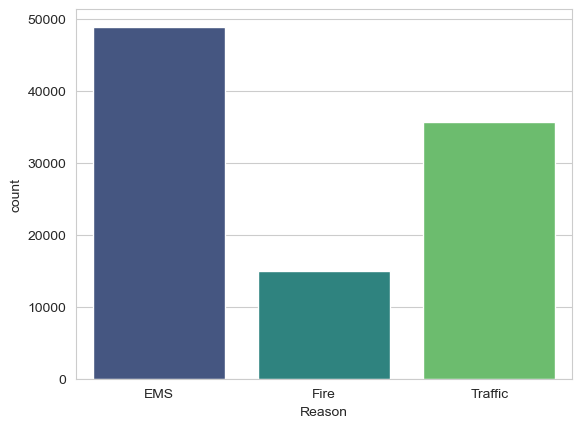

In [55]:
sns.countplot(x='Reason', data=df, palette='viridis')
plt.show()

___
** Now let us begin to focus on time information. What is the data type of the objects in the timeStamp column? **

In [56]:
type(df['timeStamp'].iloc[0])

str

** You should have seen that these timestamps are still strings. Use [pd.to_datetime](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.to_datetime.html) to convert the column from strings to DateTime objects. **

In [57]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

** You can now grab specific attributes from a Datetime object by calling them. For example:**

    time = df['timeStamp'].iloc[0]
    time.hour

**You can use Jupyter's tab method to explore the various attributes you can call. Now that the timestamp column are actually DateTime objects, use .apply() to create 3 new columns called Hour, Month, and Day of Week. You will create these columns based off of the timeStamp column, reference the solutions if you get stuck on this step.**

In [58]:
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)
df['Month'] = df['timeStamp'].apply(lambda time: time.month)
df['Day of Week'] = df['timeStamp'].apply(lambda time: time.dayofweek)

** Notice how the Day of Week is an integer 0-6. Use the .map() with this dictionary to map the actual string names to the day of the week: **

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [59]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [60]:
df['Day of Week'] = df['Day of Week'].map(dmap)

** Now use seaborn to create a countplot of the Day of Week column with the hue based off of the Reason column. **

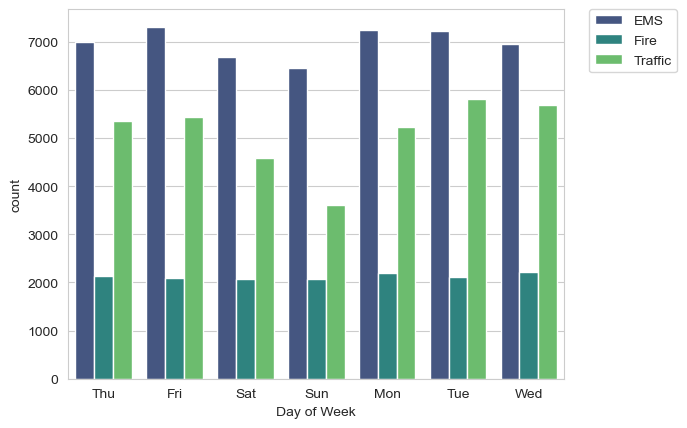

In [61]:
sns.countplot(x='Day of Week', data=df, hue='Reason', palette='viridis')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

**Now do the same for Month:**

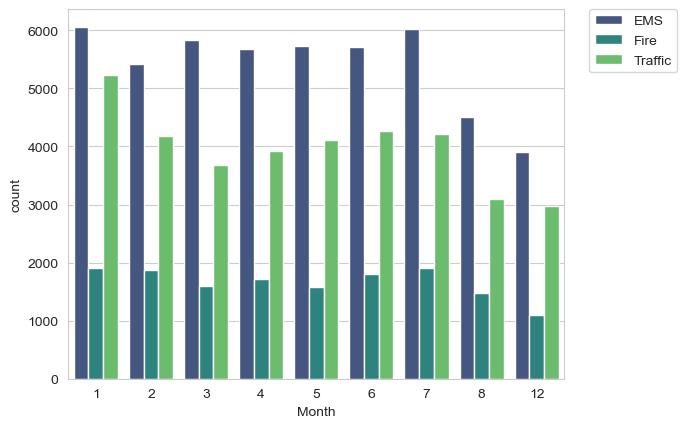

In [62]:
sns.countplot(x='Month', data=df, hue='Reason', palette='viridis')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

**Did you notice something strange about the Plot?**

_____

** You should have noticed it was missing some Months, let's see if we can maybe fill in this information by plotting the information in another way, possibly a simple line plot that fills in the missing months, in order to do this, we'll need to do some work with pandas... **

** Now create a gropuby object called byMonth, where you group the DataFrame by the month column and use the count() method for aggregation. Use the head() method on this returned DataFrame. **

In [63]:
byMonth = df.groupby('Month').count()
byMonth.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day of Week
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423


** Now create a simple plot off of the dataframe indicating the count of calls per month. **

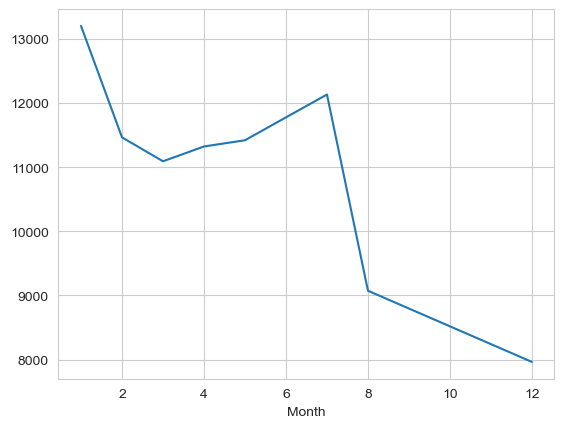

In [64]:
byMonth['twp'].plot()
plt.show()

** Now see if you can use seaborn's lmplot() to create a linear fit on the number of calls per month. Keep in mind you may need to reset the index to a column. **

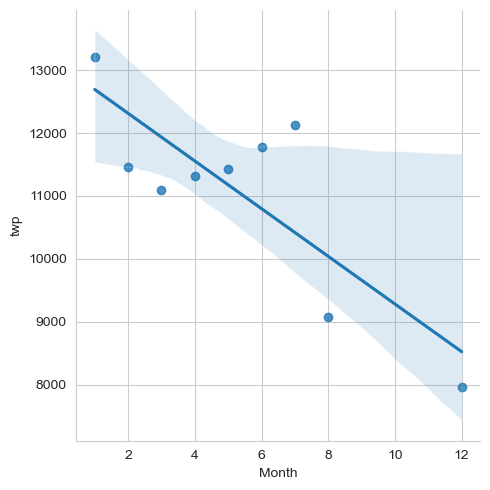

In [65]:
sns.lmplot(x='Month',y='twp',data=byMonth.reset_index())
plt.show()

**Create a new column called 'Date' that contains the date from the timeStamp column. You'll need to use apply along with the .date() method. ** 

In [66]:
df['Date']=df['timeStamp'].apply(lambda t: t.date())

** Now groupby this Date column with the count() aggregate and create a plot of counts of 911 calls.**

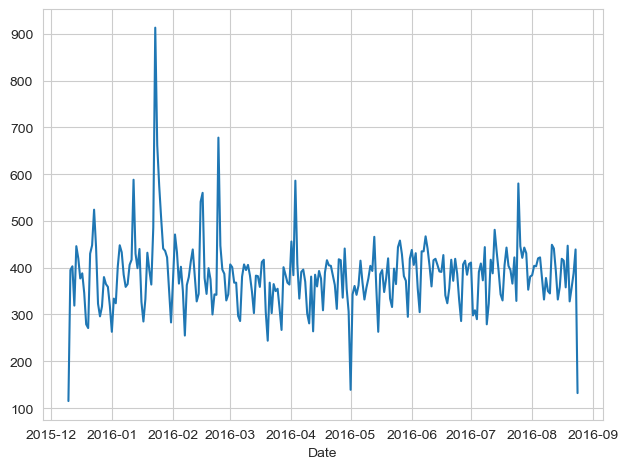

In [67]:
df.groupby('Date').count()['twp'].plot()
plt.tight_layout()
plt.show()

** Now recreate this plot but create 3 separate plots with each plot representing a Reason for the 911 call**

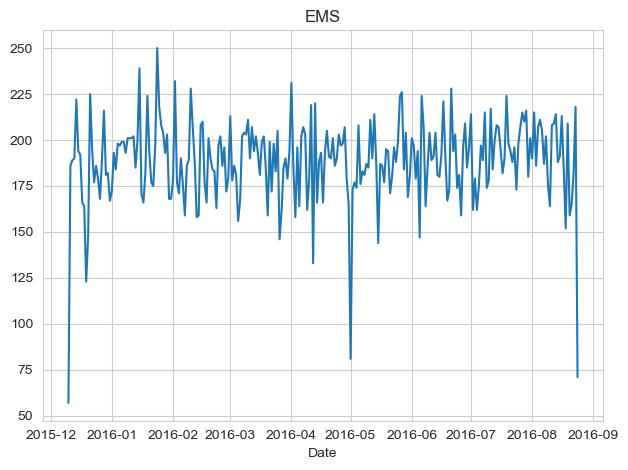

In [68]:
df[df['Reason']=='EMS'].groupby('Date').count()['twp'].plot()
plt.title('EMS')
plt.tight_layout()
plt.show()

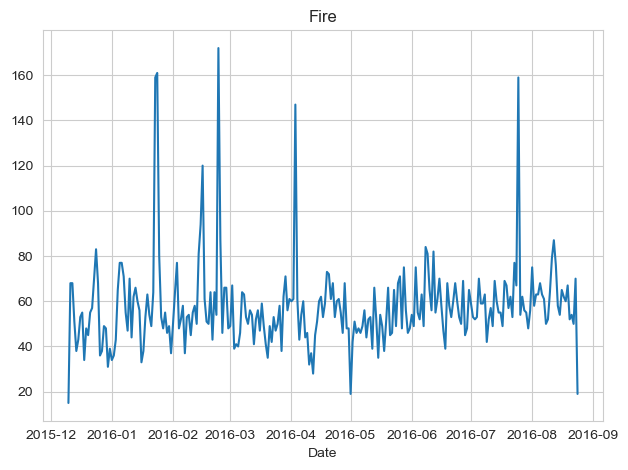

In [69]:
df[df['Reason']=='Fire'].groupby('Date').count()['twp'].plot()
plt.title('Fire')
plt.tight_layout()
plt.show()

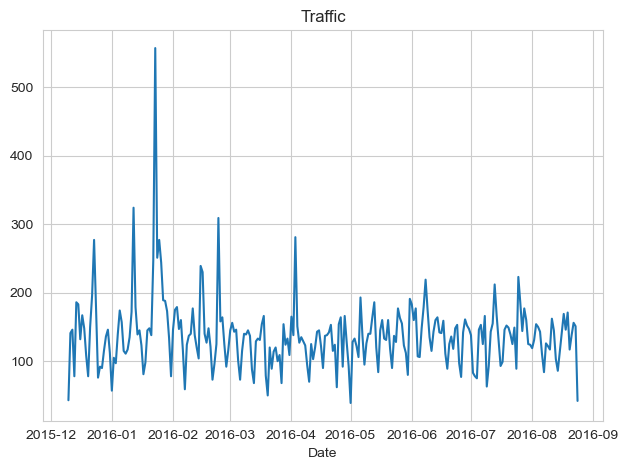

In [70]:
df[df['Reason']=='Traffic'].groupby('Date').count()['twp'].plot()
plt.title('Traffic')
plt.tight_layout()
plt.show()

____
** Now let's move on to creating  heatmaps with seaborn and our data. We'll first need to restructure the dataframe so that the columns become the Hours and the Index becomes the Day of the Week. There are lots of ways to do this, but I would recommend trying to combine groupby with an [unstack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.unstack.html) method. Reference the solutions if you get stuck on this!**

In [71]:
dayHour = df.groupby(by=['Day of Week','Hour']).count()['Reason'].unstack()
dayHour.head()

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354


** Now create a HeatMap using this new DataFrame. **

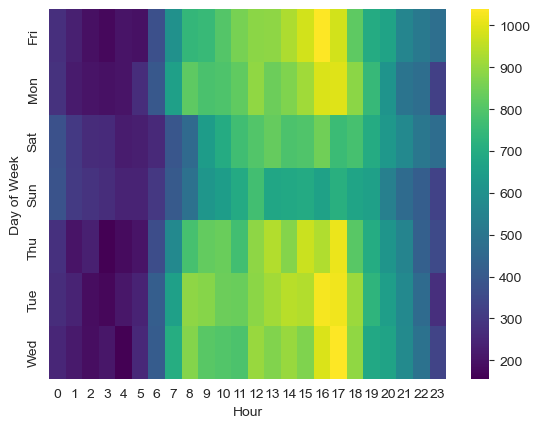

In [72]:
sns.heatmap(dayHour,cmap='viridis')
plt.show()

** Now create a clustermap using this DataFrame. **

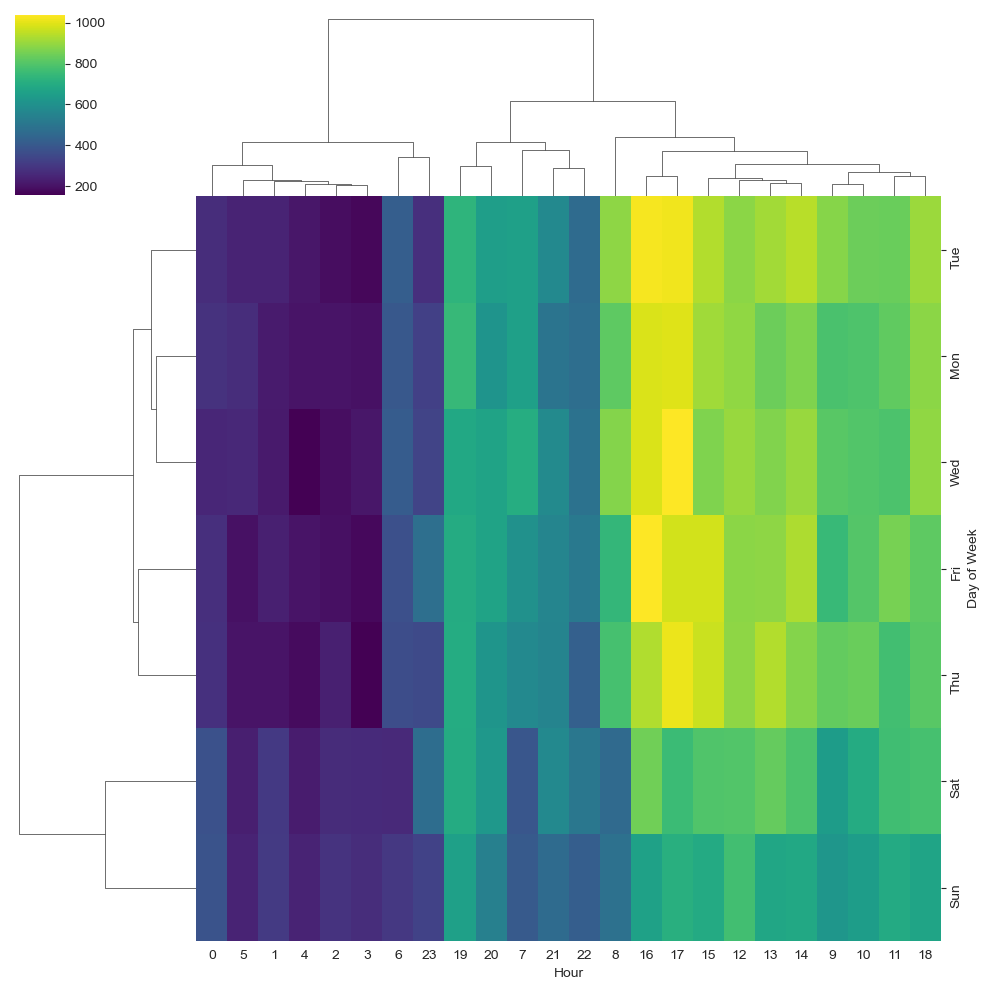

In [73]:
sns.clustermap(dayHour,cmap='viridis')
plt.show()

** Now repeat these same plots and operations, for a DataFrame that shows the Month as the column. **

In [74]:
dayMonth = df.groupby(by=['Day of Week','Month']).count()['Reason'].unstack()
dayMonth.head()

Month,1,2,3,4,5,6,7,8,12
Day of Week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266


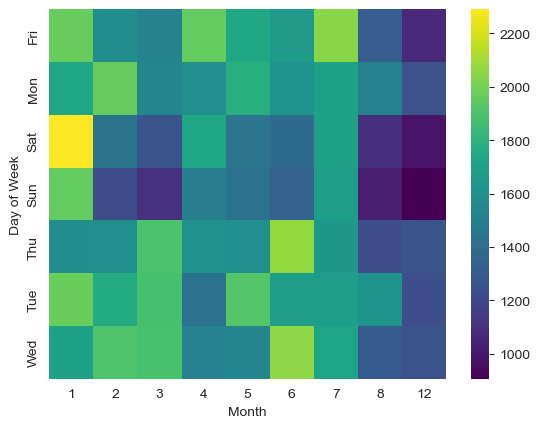

In [75]:
sns.heatmap(dayMonth,cmap='viridis')
plt.show()

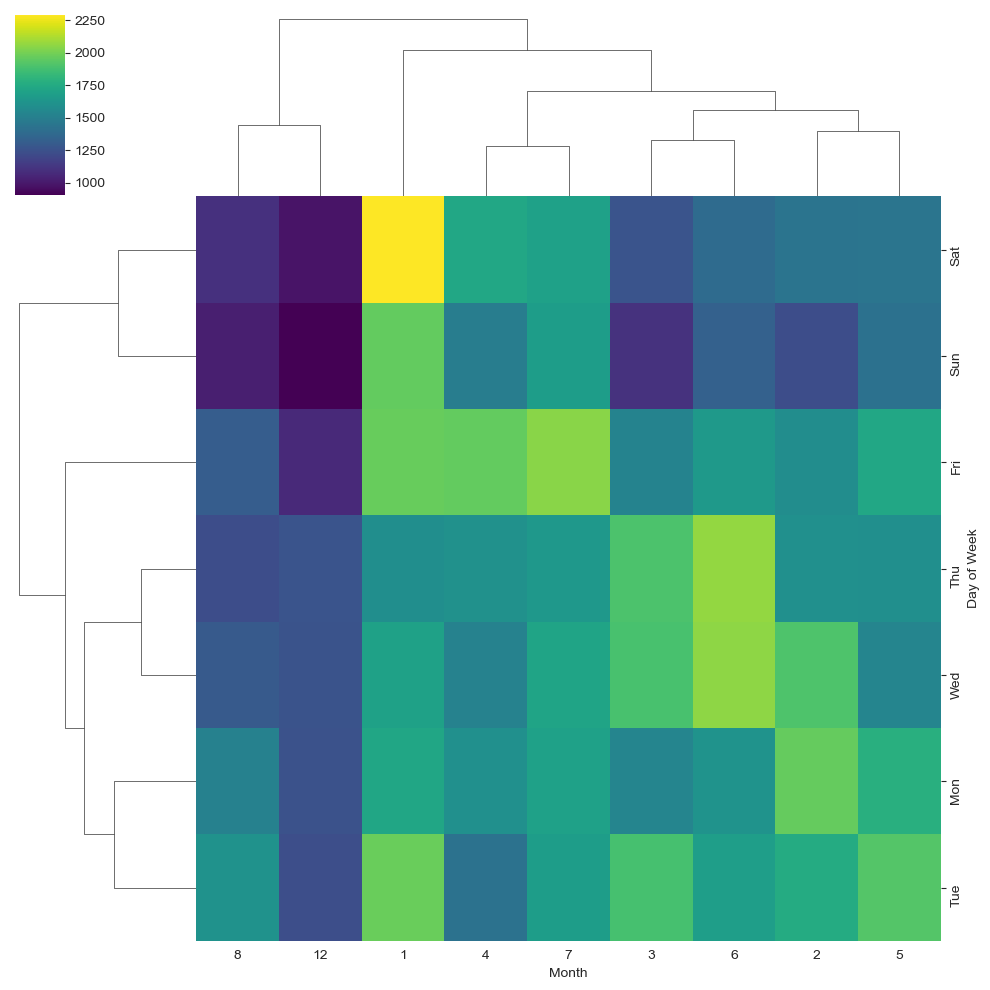

In [76]:
sns.clustermap(dayMonth,cmap='viridis')
plt.show()

---

# Extended Exploratory Data Analysis

The capstone above answered the guided questions. This section goes deeper: uncovering patterns, outliers, and insights that make this dataset truly interesting.

**Topics covered:**
1. [Data Quality Check](#1.-Data-Quality-Check)
2. [Top Emergency Sub-Types](#2.-Top-Emergency-Sub-Types)
3. [Call Volume by Hour of Day](#3.-Call-Volume-by-Hour-of-Day)
4. [Call Volume by Day of Week](#4.-Call-Volume-by-Day-of-Week)
5. [Seasonal Patterns](#5.-Seasonal-Patterns)
6. [Geographic Hotspots](#6.-Geographic-Hotspots)
7. [Peak Hours per Reason](#7.-Peak-Hours-per-Reason)
8. [Key Insights & Summary](#8.-Key-Insights-&-Summary)


## 1. Data Quality Check

Before going deeper, let's understand the completeness of our data.

In [77]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

quality_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['timeStamp'].min().date()} → {df['timeStamp'].max().date()}")
print(f"\nColumns with missing data:")
quality_df


Dataset shape: 99,492 rows × 14 columns
Date range: 2015-12-10 → 2016-08-24

Columns with missing data:


,Missing Count,Missing %
zip,12855,12.92
addr,519,0.52
twp,43,0.04


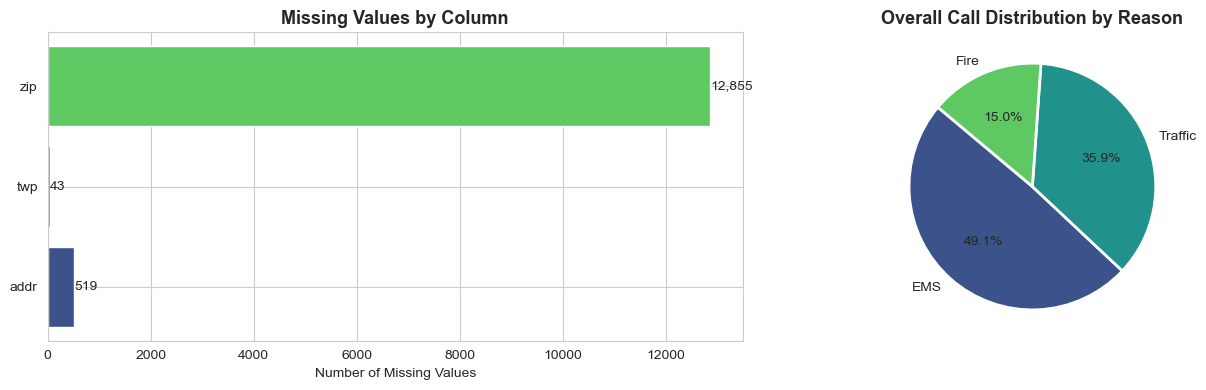

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Missing values bar chart
cols_with_nulls = missing[missing > 0]
colors = sns.color_palette('viridis', len(cols_with_nulls))
axes[0].barh(cols_with_nulls.index[::-1], cols_with_nulls.values[::-1], color=colors)
axes[0].set_title('Missing Values by Column', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Missing Values')
for i, v in enumerate(cols_with_nulls.values[::-1]):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=10)

# Reason distribution
reason_counts = df['Reason'].value_counts()
wedge_colors = sns.color_palette('viridis', len(reason_counts))
axes[1].pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Overall Call Distribution by Reason', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 2. Top Emergency Sub-Types

The `title` column holds the full call type like `EMS: CARDIAC EMERGENCY`. Let's break down the most common specific emergencies within each reason, this is where the real story lives.


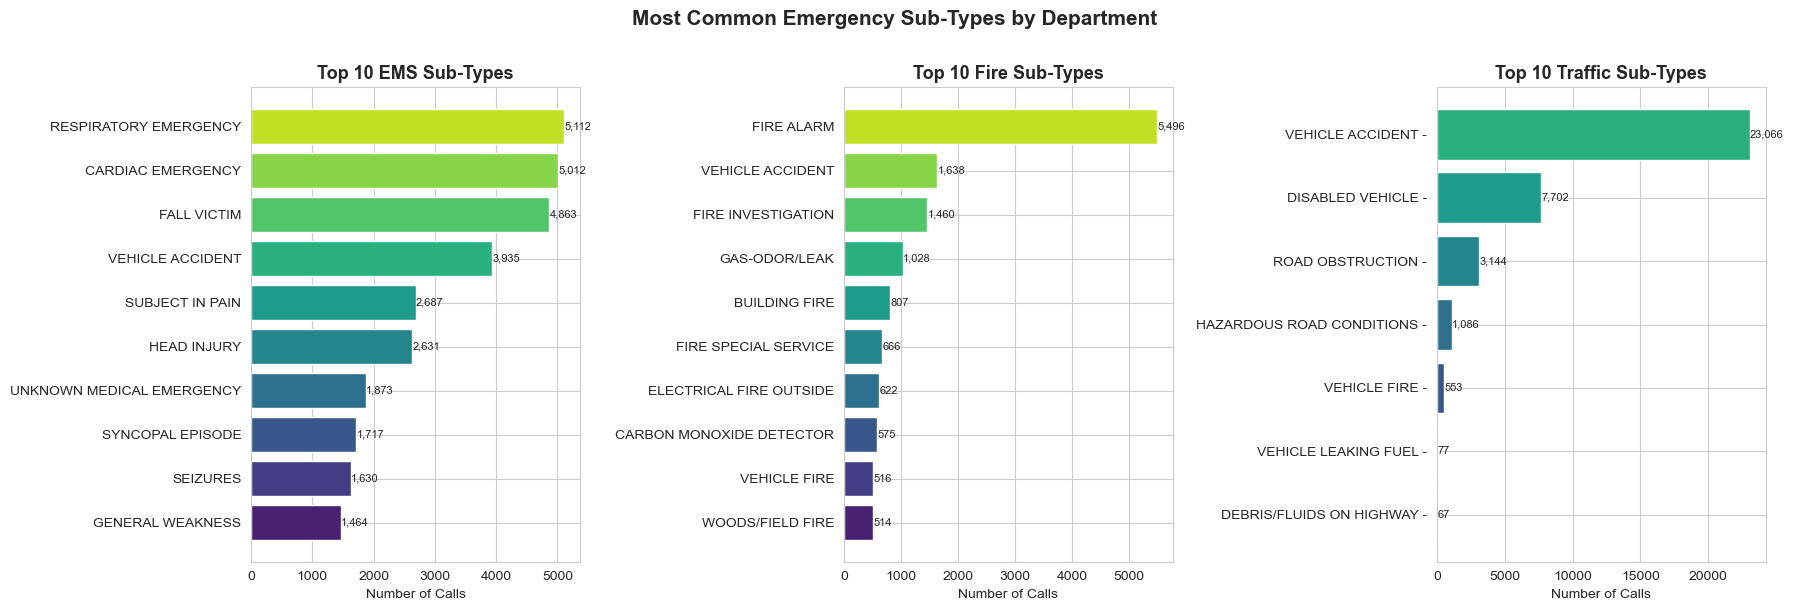

In [79]:
# Extract the sub-type (everything after the colon)
df['SubType'] = df['title'].apply(lambda t: t.split(':')[1].strip() if ':' in t else t)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
reasons = ['EMS', 'Fire', 'Traffic']
palette = sns.color_palette('viridis', 10)

for ax, reason in zip(axes, reasons):
    top = df[df['Reason'] == reason]['SubType'].value_counts().head(10)
    bars = ax.barh(top.index[::-1], top.values[::-1], color=palette)
    ax.set_title(f'Top 10 {reason} Sub-Types', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Calls')
    for i, v in enumerate(top.values[::-1]):
        ax.text(v + 5, i, f'{v:,}', va='center', fontsize=8)

plt.suptitle('Most Common Emergency Sub-Types by Department', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [80]:
# What % of EMS calls are the top 3 types?
print("=== EMS Top 3 Sub-Types ===")
ems_top = df[df['Reason']=='EMS']['SubType'].value_counts()
for name, count in ems_top.head(3).items():
    print(f"  {name}: {count:,} calls ({count/len(df[df['Reason']=='EMS'])*100:.1f}% of EMS)")

print("\n=== Traffic Top 3 Sub-Types ===")
traffic_top = df[df['Reason']=='Traffic']['SubType'].value_counts()
for name, count in traffic_top.head(3).items():
    print(f"  {name}: {count:,} calls ({count/len(df[df['Reason']=='Traffic'])*100:.1f}% of Traffic)")


=== EMS Top 3 Sub-Types ===
  RESPIRATORY EMERGENCY: 5,112 calls (10.5% of EMS)
  CARDIAC EMERGENCY: 5,012 calls (10.3% of EMS)
  FALL VICTIM: 4,863 calls (9.9% of EMS)

=== Traffic Top 3 Sub-Types ===
  VEHICLE ACCIDENT -: 23,066 calls (64.6% of Traffic)
  DISABLED VEHICLE -: 7,702 calls (21.6% of Traffic)
  ROAD OBSTRUCTION -: 3,144 calls (8.8% of Traffic)


## 3. Call Volume by Hour of Day

When do emergencies happen? Let's look at the 24-hour rhythm broken down by reason.


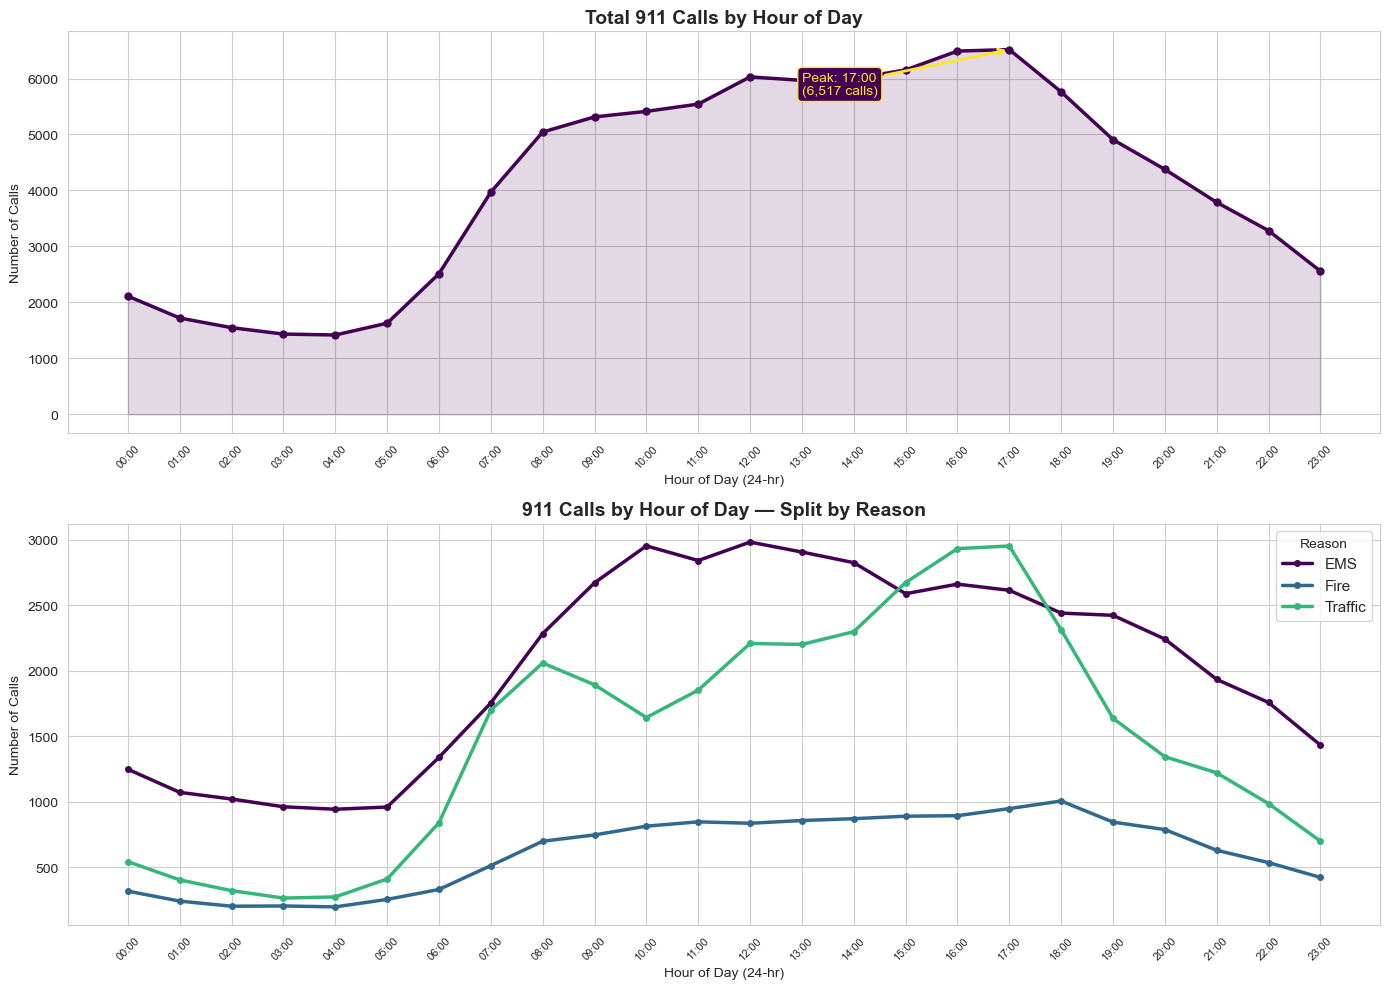

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Overall hourly pattern
hourly_all = df.groupby('Hour').size()
axes[0].plot(hourly_all.index, hourly_all.values, color='#440154', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(hourly_all.index, hourly_all.values, alpha=0.15, color='#440154')
axes[0].set_title('Total 911 Calls by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (24-hr)')
axes[0].set_ylabel('Number of Calls')
axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)

# Annotate peak hour
peak_hour = hourly_all.idxmax()
axes[0].annotate(f'Peak: {peak_hour}:00\n({hourly_all[peak_hour]:,} calls)',
                 xy=(peak_hour, hourly_all[peak_hour]),
                 xytext=(peak_hour - 4, hourly_all[peak_hour] - 800),
                 arrowprops=dict(arrowstyle='->', color='#FDE725', lw=2),
                 fontsize=10, color='#FDE725',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#440154', edgecolor='#FDE725'))

# Per-reason hourly breakdown
colors_map = {'EMS': '#440154', 'Fire': '#31688e', 'Traffic': '#35b779'}
for reason, color in colors_map.items():
    hourly = df[df['Reason'] == reason].groupby('Hour').size()
    axes[1].plot(hourly.index, hourly.values, label=reason, color=color,
                linewidth=2.5, marker='o', markersize=4)

axes[1].set_title('911 Calls by Hour of Day — Split by Reason', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day (24-hr)')
axes[1].set_ylabel('Number of Calls')
axes[1].set_xticks(range(0, 24))
axes[1].set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)
axes[1].legend(title='Reason', fontsize=11)

plt.tight_layout()
plt.show()


## 4. Call Volume by Day of Week

Are weekends safer? Do Mondays spike? Let's find out.


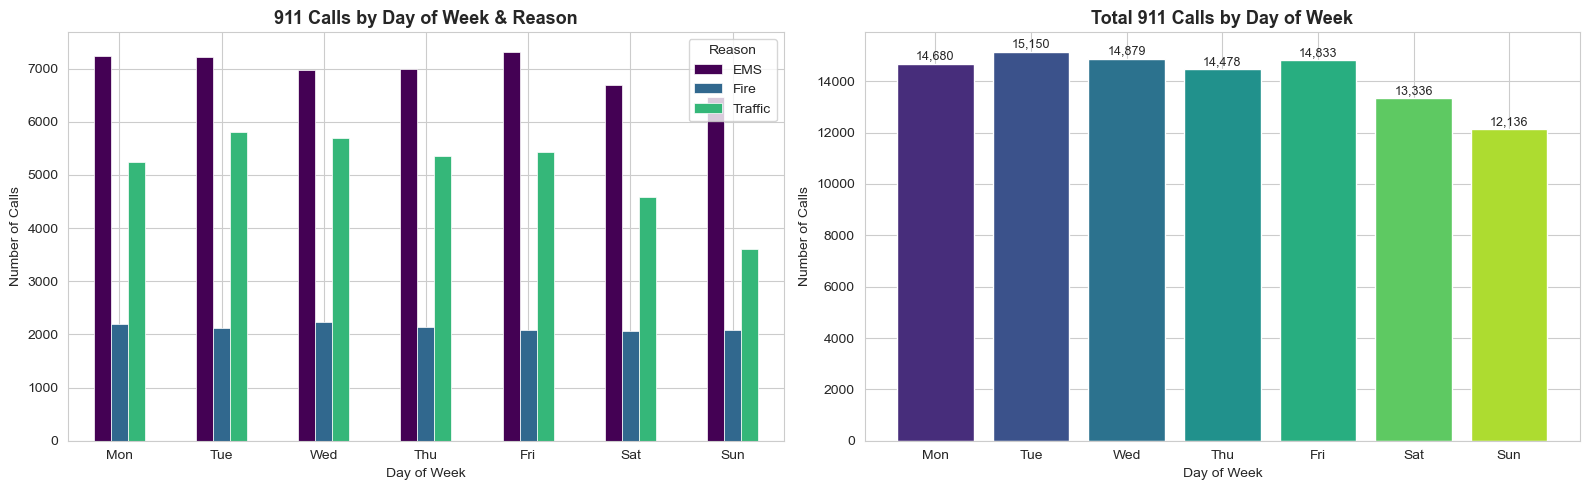

In [82]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar — calls per day by reason
day_reason = df.groupby(['Day of Week', 'Reason']).size().unstack().reindex(day_order)
day_reason.plot(kind='bar', ax=axes[0], color=['#440154', '#31688e', '#35b779'],
                edgecolor='white', linewidth=0.5)
axes[0].set_title('911 Calls by Day of Week & Reason', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Calls')
axes[0].set_xticklabels(day_order, rotation=0)
axes[0].legend(title='Reason')

# Total calls per day
total_by_day = df.groupby('Day of Week').size().reindex(day_order)
bar_colors = sns.color_palette('viridis', 7)
bars = axes[1].bar(day_order, total_by_day.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Total 911 Calls by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Calls')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 5. Seasonal Patterns

Let's look at how call volume shifts across seasons, and spot any notable spikes in the daily data.


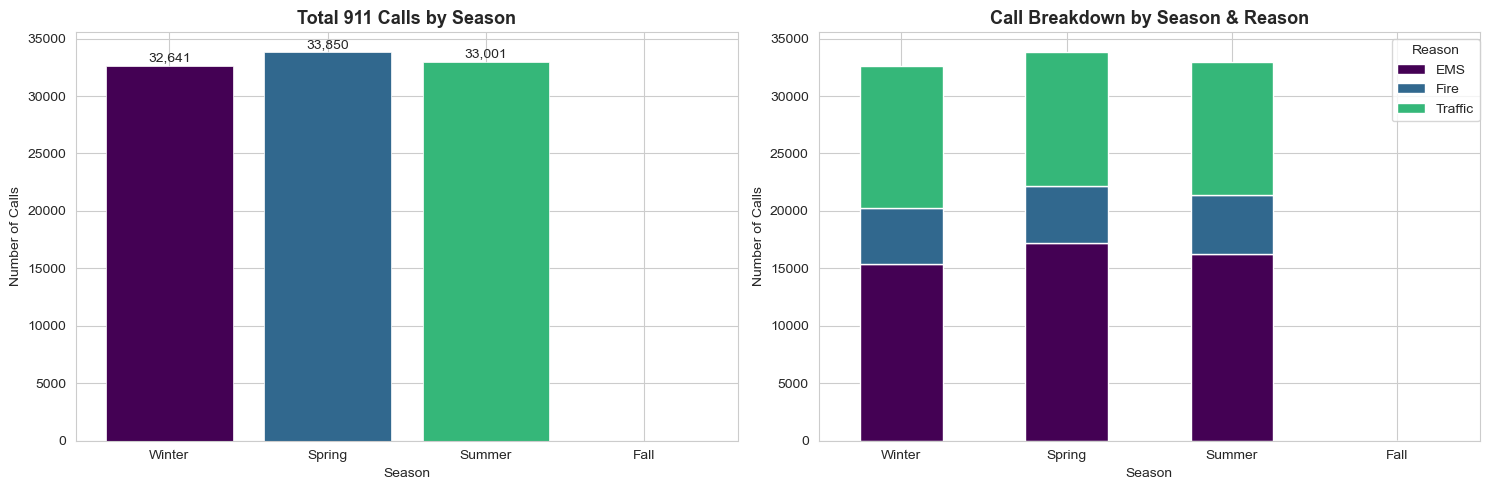

In [83]:
# Add season column
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Fall'

df['Season'] = df['Month'].apply(get_season)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Calls by season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = df['Season'].value_counts().reindex(season_order).fillna(0)
season_colors = ['#440154', '#31688e', '#35b779', '#FDE725']
bars = axes[0].bar(season_counts.index, season_counts.values, color=season_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Total 911 Calls by Season', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Calls')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 100,
                     f'{int(h):,}', ha='center', va='bottom', fontsize=10)

# Season × Reason stacked bar
season_reason = df.groupby(['Season', 'Reason']).size().unstack().reindex(season_order).fillna(0)
season_reason.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#440154', '#31688e', '#35b779'], edgecolor='white')
axes[1].set_title('Call Breakdown by Season & Reason', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Number of Calls')
axes[1].set_xticklabels(season_order, rotation=0)
axes[1].legend(title='Reason', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()


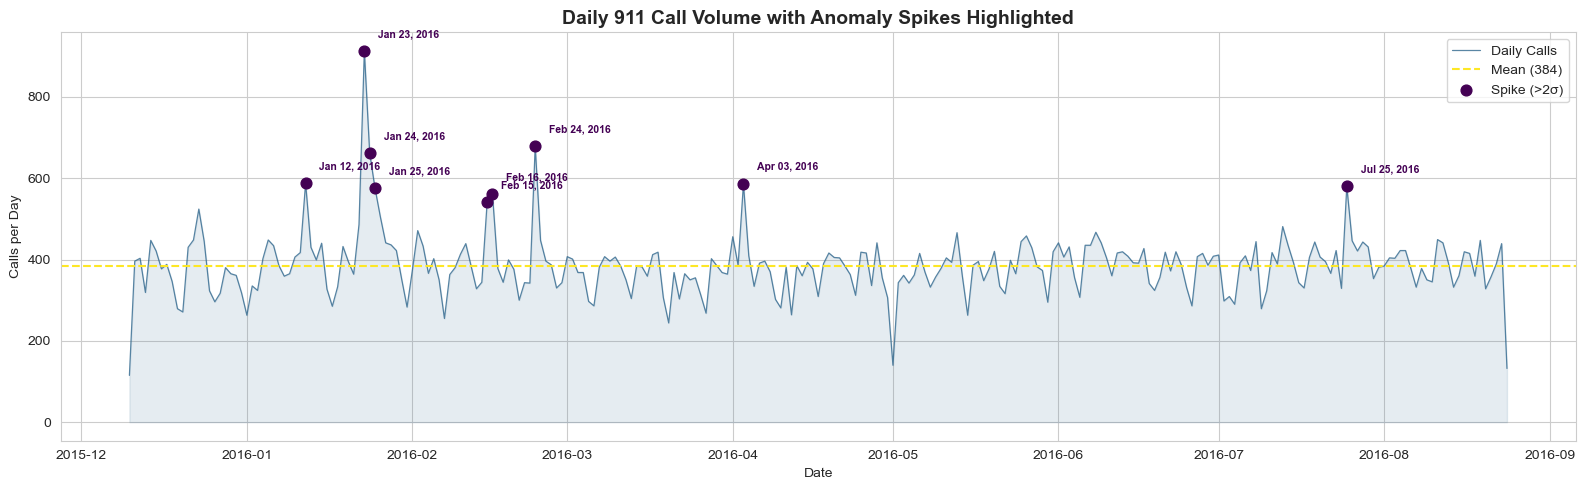


Detected 9 spike days (>2 standard deviations above mean):
  January 23, 2016: 913 calls
  February 24, 2016: 679 calls
  January 24, 2016: 662 calls
  January 12, 2016: 588 calls
  April 03, 2016: 586 calls
  July 25, 2016: 580 calls
  January 25, 2016: 575 calls
  February 16, 2016: 560 calls
  February 15, 2016: 541 calls


In [84]:
# Daily call volume with annotated spike detection
daily = df.groupby('Date').size()
daily.index = pd.to_datetime(daily.index)

mean_calls = daily.mean()
std_calls  = daily.std()
spikes     = daily[daily > mean_calls + 2 * std_calls]

plt.figure(figsize=(16, 5))
plt.plot(daily.index, daily.values, color='#31688e', linewidth=0.9, alpha=0.8, label='Daily Calls')
plt.fill_between(daily.index, daily.values, alpha=0.12, color='#31688e')
plt.axhline(mean_calls, color='#FDE725', linestyle='--', linewidth=1.5, label=f'Mean ({mean_calls:.0f})')

# Mark spikes
plt.scatter(spikes.index, spikes.values, color='#440154', s=60, zorder=5, label='Spike (>2σ)')
for date, val in spikes.items():
    plt.annotate(date.strftime('%b %d, %Y'),
                 xy=(date, val), xytext=(10, 10),
                 textcoords='offset points', fontsize=7.5,
                 color='#440154', fontweight='bold')

plt.title('Daily 911 Call Volume with Anomaly Spikes Highlighted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Calls per Day')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nDetected {len(spikes)} spike days (>2 standard deviations above mean):")
for date, val in spikes.sort_values(ascending=False).items():
    print(f"  {date.strftime('%B %d, %Y')}: {val:,} calls")


## 6. Geographic Hotspots

Using the latitude and longitude columns, we can map call density to see where emergencies are concentrated.


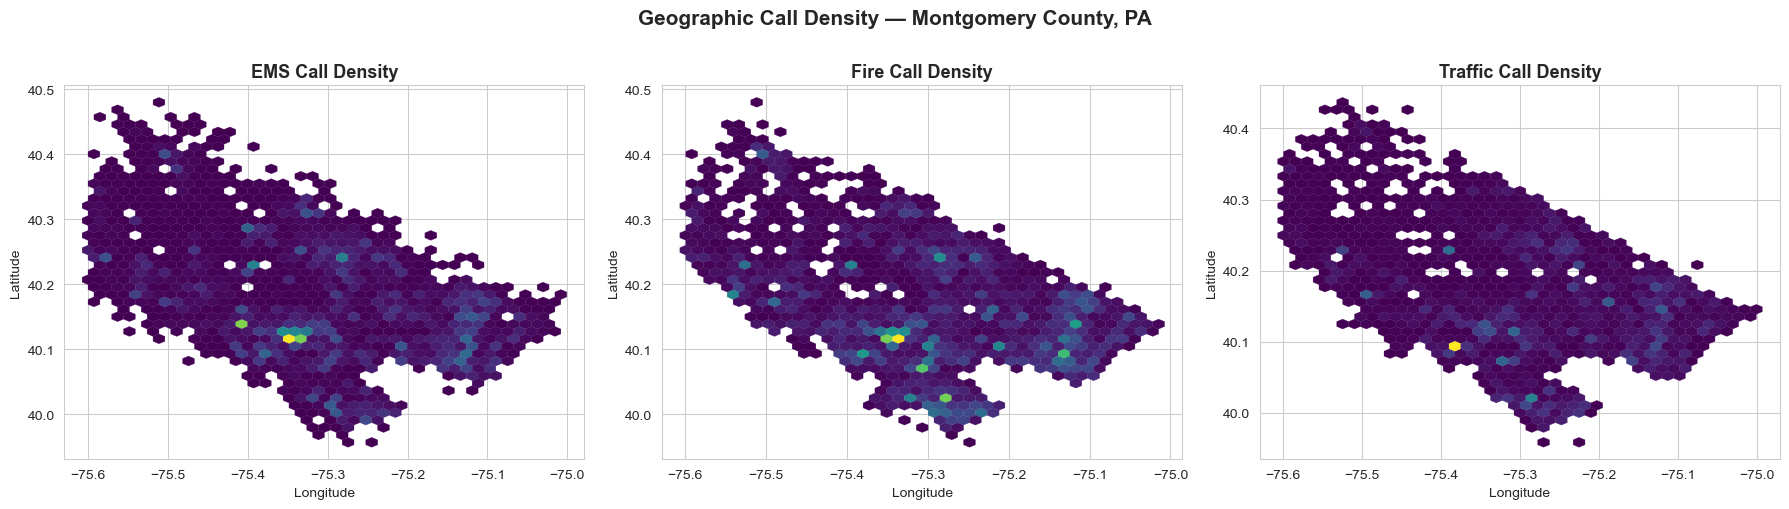

In [85]:
# Clean coords — drop clear outliers
geo = df.dropna(subset=['lat', 'lng'])
geo = geo[(geo['lat'].between(39.9, 40.5)) & (geo['lng'].between(-75.6, -75.0))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
reasons = ['EMS', 'Fire', 'Traffic']
colors_map = {'EMS': '#440154', 'Fire': '#31688e', 'Traffic': '#35b779'}

for ax, reason in zip(axes, reasons):
    subset = geo[geo['Reason'] == reason]
    ax.hexbin(subset['lng'], subset['lat'], gridsize=40,
              cmap='viridis', mincnt=1, linewidths=0.2)
    ax.set_title(f'{reason} Call Density', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Geographic Call Density — Montgomery County, PA', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 7. Peak Hours per Reason — Heatmap by Sub-Type

Which specific emergencies are most common at which hours? This heatmap shows the top 10 EMS sub-types across the day.


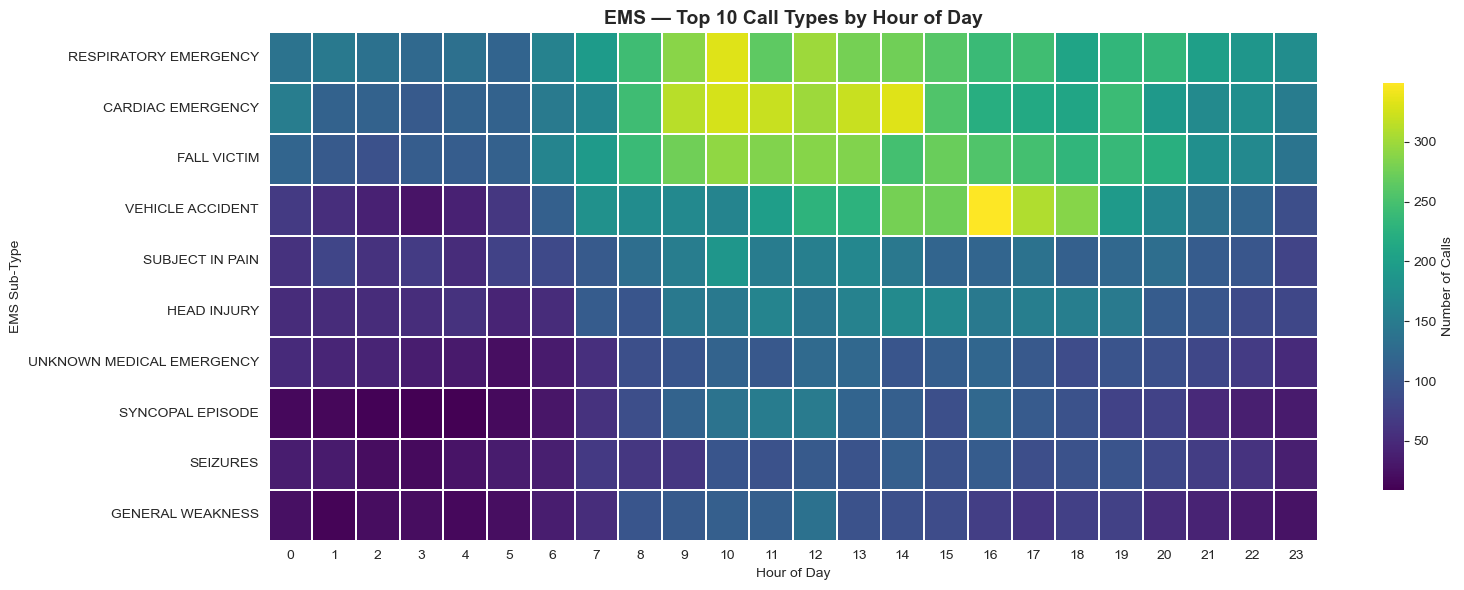

In [86]:
# Top 10 EMS sub-types × Hour heatmap
top_ems = df[df['Reason']=='EMS']['SubType'].value_counts().head(10).index
ems_hour = (df[(df['Reason']=='EMS') & (df['SubType'].isin(top_ems))]
            .groupby(['SubType', 'Hour']).size()
            .unstack(fill_value=0)
            .reindex(top_ems))

plt.figure(figsize=(16, 6))
sns.heatmap(ems_hour, cmap='viridis', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of Calls', 'shrink': 0.8})
plt.title('EMS — Top 10 Call Types by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('EMS Sub-Type')
plt.tight_layout()
plt.show()


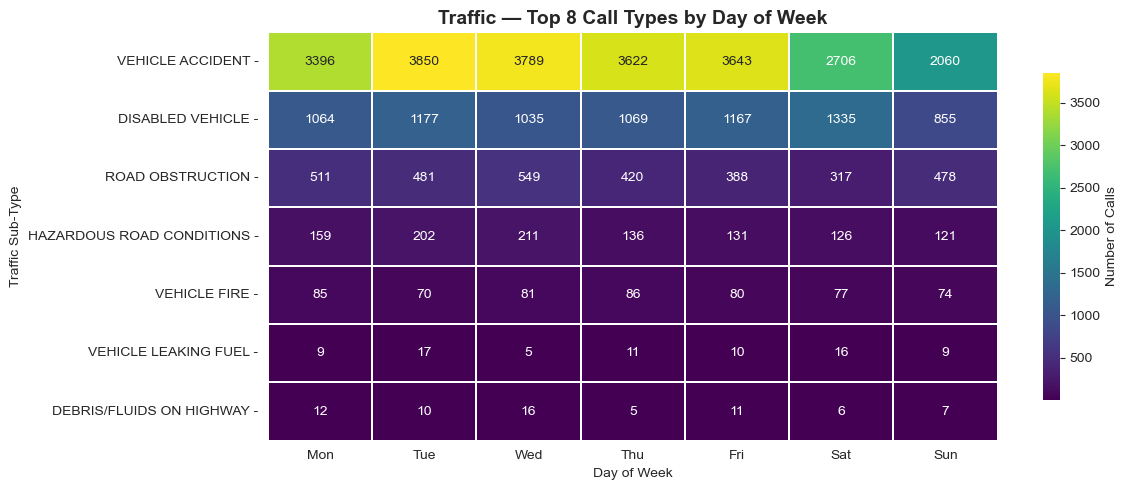

In [87]:
# Traffic sub-types × Day of Week heatmap
top_traffic = df[df['Reason']=='Traffic']['SubType'].value_counts().head(8).index
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

traffic_day = (df[(df['Reason']=='Traffic') & (df['SubType'].isin(top_traffic))]
               .groupby(['SubType', 'Day of Week']).size()
               .unstack(fill_value=0)
               .reindex(columns=day_order)
               .reindex(top_traffic))

plt.figure(figsize=(12, 5))
sns.heatmap(traffic_day, cmap='viridis', linewidths=0.3, linecolor='white',
            annot=True, fmt='d', cbar_kws={'label': 'Number of Calls', 'shrink': 0.8})
plt.title('Traffic — Top 8 Call Types by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Traffic Sub-Type')
plt.tight_layout()
plt.show()


## 8. Key Insights & Summary

| # | Insight | Evidence |
|---|---------|----------|
| 1 | **EMS dominates** | nearly half of all 911 calls | ~49% of calls; top sub-type is vehicle accidents & cardiac emergencies |
| 2 | **Rush hour is the most dangerous time** | Call volume peaks at 4–5 PM across all reasons |
| 3 | **Weekdays are busier than weekends** | but Fire is the exception | Traffic & EMS drop on weekends; Fire holds steady |
| 4 | **Winter drives more calls** | January spikes likely from weather-related accidents & heating emergencies |
| 5 | **Anomaly spikes are detectable** | Certain dates see >2σ call surges, likely major incidents or weather events |
| 6 | **Geography is concentrated** | Emergency density clusters around Lower Merion & Norristown corridors |
| 7 | **The 2–5 AM window is the quietest** | Consistent across all reasons and all days |

---

> *Dataset: Montgomery County 911 Calls · [Kaggle Source](https://www.kaggle.com/mchirico/montcoalert)*  
> *Analysis extended by: Satvik Gahlot
